FORECASTING POWER SUPPLY DEMAND

EXPLORATORY DATA ANALYSIS (EDA)

In [3]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [4]:
#Loading the dataset
df=pd.read_excel('PJMW_MW_Hourly.xlsx')
df

,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077
1,2002-12-31 02:00:00,4939
2,2002-12-31 03:00:00,4885
3,2002-12-31 04:00:00,4857
4,2002-12-31 05:00:00,4930
...,...,...
143201,2018-01-01 20:00:00,8401
143202,2018-01-01 21:00:00,8373
143203,2018-01-01 22:00:00,8238
143204,2018-01-01 23:00:00,7958


In [5]:
#Shape of the dataset
df.shape

(143206, 2)

In [6]:
#Size of the dataset
df.size

286412

In [7]:
#Columns in the dataset
df.columns

Index(['Datetime', 'PJMW_MW'], dtype='object')

In [8]:
#Basic information of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  143206 non-null  datetime64[ns]
 1   PJMW_MW   143206 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.2 MB


In [9]:
#Central Tendencies of the numerical columns
df.describe()

,Datetime,PJMW_MW
count,143206,143206.000000
mean,2010-06-02 03:39:50.656816128,5602.375089
min,2002-04-01 01:00:00,487.000000
25%,2006-05-02 03:15:00,4907.000000
50%,2010-06-02 04:30:00,5530.000000
75%,2014-07-03 06:45:00,6252.000000
max,2018-08-03 00:00:00,9594.000000
std,NaN,979.142872


In [10]:
#Checking null values
df.isnull().sum()

,0
Datetime,0
PJMW_MW,0


In [11]:
#Checking duplicates in whole dataset
df.duplicated().sum()

np.int64(0)

In [12]:
#Checking duplicates present in the Datetime
df[df['Datetime'].duplicated()]

,Datetime,PJMW_MW
104425,2014-11-02 02:00:00,4571
113209,2015-11-01 02:00:00,3832
121849,2016-11-06 02:00:00,4089
130657,2017-11-05 02:00:00,3984


In [13]:
#Exploring the start and end of column
print("Start:", df["Datetime"].min())
print("End:", df["Datetime"].max())

Start: 2002-04-01 01:00:00
End: 2018-08-03 00:00:00


In [14]:
# Convert the Datetime objects to datetime columns
# Sorting the data chronologically for better understanding of every records
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime").reset_index(drop=True)
print(df.head(10))

             Datetime  PJMW_MW
0 2002-04-01 01:00:00     4374
1 2002-04-01 02:00:00     4306
2 2002-04-01 03:00:00     4322
3 2002-04-01 04:00:00     4359
4 2002-04-01 05:00:00     4436
5 2002-04-01 06:00:00     4723
6 2002-04-01 07:00:00     5180
7 2002-04-01 08:00:00     5482
8 2002-04-01 09:00:00     5616
9 2002-04-01 10:00:00     5722


In [15]:
df['Datetime']

,Datetime
0,2002-04-01 01:00:00
1,2002-04-01 02:00:00
2,2002-04-01 03:00:00
3,2002-04-01 04:00:00
4,2002-04-01 05:00:00
...,...
143201,2018-08-02 20:00:00
143202,2018-08-02 21:00:00
143203,2018-08-02 22:00:00
143204,2018-08-02 23:00:00


In [16]:
# Calculate time intervals between consecutive timestamps and check frequency of each time gap
df["time_diff"] = df["Datetime"].diff()
print(df["time_diff"].value_counts())

time_diff
0 days 01:00:00    143171
0 days 02:00:00        30
0 days 00:00:00         4
Name: count, dtype: int64


In [17]:
# Identify and display instances where the time interval between consecutive timestamps exceeds 1 hour (missing hours)
gaps = df[df["time_diff"] > pd.Timedelta(hours=1)]
print("Number of gaps:", len(gaps))
print(gaps[["Datetime", "time_diff"]].head(20))

Number of gaps: 30
                 Datetime       time_diff
146   2002-04-07 04:00:00 0 days 02:00:00
5016  2002-10-27 03:00:00 0 days 02:00:00
8880  2003-04-06 04:00:00 0 days 02:00:00
13750 2003-10-26 03:00:00 0 days 02:00:00
17614 2004-04-04 04:00:00 0 days 02:00:00
22652 2004-10-31 03:00:00 0 days 02:00:00
26348 2005-04-03 04:00:00 0 days 02:00:00
31386 2005-10-30 03:00:00 0 days 02:00:00
35082 2006-04-02 04:00:00 0 days 02:00:00
40120 2006-10-29 03:00:00 0 days 02:00:00
43312 2007-03-11 04:00:00 0 days 02:00:00
49022 2007-11-04 03:00:00 0 days 02:00:00
52046 2008-03-09 04:00:00 0 days 02:00:00
57756 2008-11-02 03:00:00 0 days 02:00:00
60780 2009-03-08 04:00:00 0 days 02:00:00
66490 2009-11-01 03:00:00 0 days 02:00:00
69682 2010-03-14 04:00:00 0 days 02:00:00
75392 2010-11-07 03:00:00 0 days 02:00:00
76181 2010-12-10 01:00:00 0 days 02:00:00
78415 2011-03-13 04:00:00 0 days 02:00:00


In [18]:
# Filter and display the first 20 records with non-standard time intervals (gaps, duplicates, or initial NaT)
print(df[df["time_diff"] != pd.Timedelta(hours=1)][["Datetime", "time_diff"]].head(20))

                 Datetime       time_diff
0     2002-04-01 01:00:00             NaT
146   2002-04-07 04:00:00 0 days 02:00:00
5016  2002-10-27 03:00:00 0 days 02:00:00
8880  2003-04-06 04:00:00 0 days 02:00:00
13750 2003-10-26 03:00:00 0 days 02:00:00
17614 2004-04-04 04:00:00 0 days 02:00:00
22652 2004-10-31 03:00:00 0 days 02:00:00
26348 2005-04-03 04:00:00 0 days 02:00:00
31386 2005-10-30 03:00:00 0 days 02:00:00
35082 2006-04-02 04:00:00 0 days 02:00:00
40120 2006-10-29 03:00:00 0 days 02:00:00
43312 2007-03-11 04:00:00 0 days 02:00:00
49022 2007-11-04 03:00:00 0 days 02:00:00
52046 2008-03-09 04:00:00 0 days 02:00:00
57756 2008-11-02 03:00:00 0 days 02:00:00
60780 2009-03-08 04:00:00 0 days 02:00:00
66490 2009-11-01 03:00:00 0 days 02:00:00
69682 2010-03-14 04:00:00 0 days 02:00:00
75392 2010-11-07 03:00:00 0 days 02:00:00
76181 2010-12-10 01:00:00 0 days 02:00:00


In [19]:
#Identify all duplicate timestamp indices and display a 5-row context window around each occurrence
duplicate_indices = df.index[df["Datetime"].duplicated(keep=False)]
for idx in duplicate_indices:
    print(" ")
    print(df.loc[idx-2:idx+2, ["Datetime", "PJMW_MW"]])

 
                  Datetime  PJMW_MW
110325 2014-11-02 00:00:00     4912
110326 2014-11-02 01:00:00     4805
110327 2014-11-02 02:00:00     4571
110328 2014-11-02 02:00:00     4613
110329 2014-11-02 03:00:00     4619
 
                  Datetime  PJMW_MW
110326 2014-11-02 01:00:00     4805
110327 2014-11-02 02:00:00     4571
110328 2014-11-02 02:00:00     4613
110329 2014-11-02 03:00:00     4619
110330 2014-11-02 04:00:00     4615
 
                  Datetime  PJMW_MW
119061 2015-11-01 00:00:00     4194
119062 2015-11-01 01:00:00     4014
119063 2015-11-01 02:00:00     3927
119064 2015-11-01 02:00:00     3832
119065 2015-11-01 03:00:00     3741
 
                  Datetime  PJMW_MW
119062 2015-11-01 01:00:00     4014
119063 2015-11-01 02:00:00     3927
119064 2015-11-01 02:00:00     3832
119065 2015-11-01 03:00:00     3741
119066 2015-11-01 04:00:00     3763
 
                  Datetime  PJMW_MW
127965 2016-11-06 00:00:00     4486
127966 2016-11-06 01:00:00     4258
127967 2016-11-06 

In [20]:
# Duplicate timpestamps
duplicates = df[df["Datetime"].duplicated(keep=False)]
print(duplicates[["Datetime", "PJMW_MW"]])

                  Datetime  PJMW_MW
110327 2014-11-02 02:00:00     4571
110328 2014-11-02 02:00:00     4613
119063 2015-11-01 02:00:00     3927
119064 2015-11-01 02:00:00     3832
127967 2016-11-06 02:00:00     4114
127968 2016-11-06 02:00:00     4089
136703 2017-11-05 02:00:00     3984
136704 2017-11-05 02:00:00     4042


In [21]:
df = df.drop(columns="time_diff")

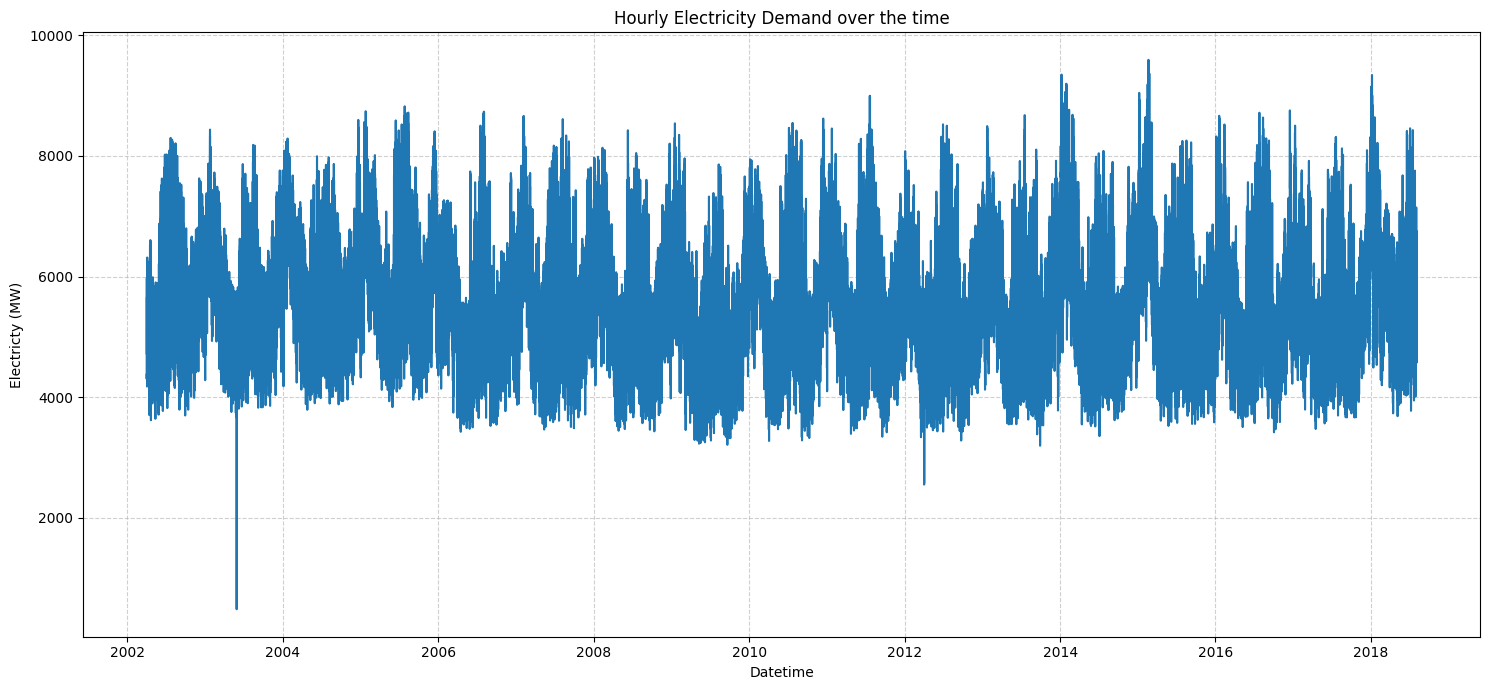

In [22]:
# Hourly electricity demand over the time(Whole Dataset)
plt.figure(figsize = (15,7))

plt.plot(df["Datetime"],df["PJMW_MW"])
plt.title("Hourly Electricity Demand over the time")
plt.xlabel("Datetime")
plt.ylabel("Electricty (MW)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

1.The demand generally fluctuates between approximately 3,500 MW and 8,000 MW, with occasional peaks approaching 9,500 MW and some unusually low observations.
2.The graph is very dense because the dataset contains hourly observations over many years.
3.The electricity consumption changes continuously over time as time plays role in uage of electricity in different ways.
The overall time-series graph shows that electricity demand is highly variable and contains repeated daily, weekly and seasonal patterns. This confirms that time-dependent and historical consumption features are necessary for forecasting.

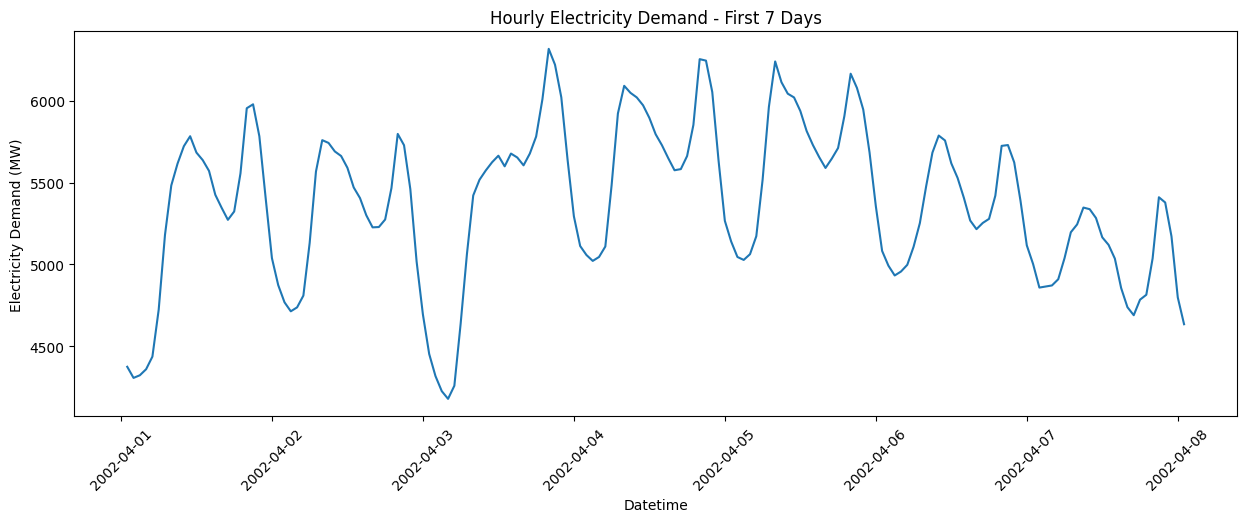

In [23]:
# First Week's hourly electricity demand
first_week = df.iloc[:168]

plt.figure(figsize=(15, 5))
plt.plot(first_week["Datetime"], first_week["PJMW_MW"])
plt.title("Hourly Electricity Demand - First 7 Days")
plt.xlabel("Datetime")
plt.ylabel("Electricity Demand (MW)")
plt.xticks(rotation=45)
plt.show()

Night →Low demand→ Morning increases→ Daytime high demand→ Evening varies→ Night decline

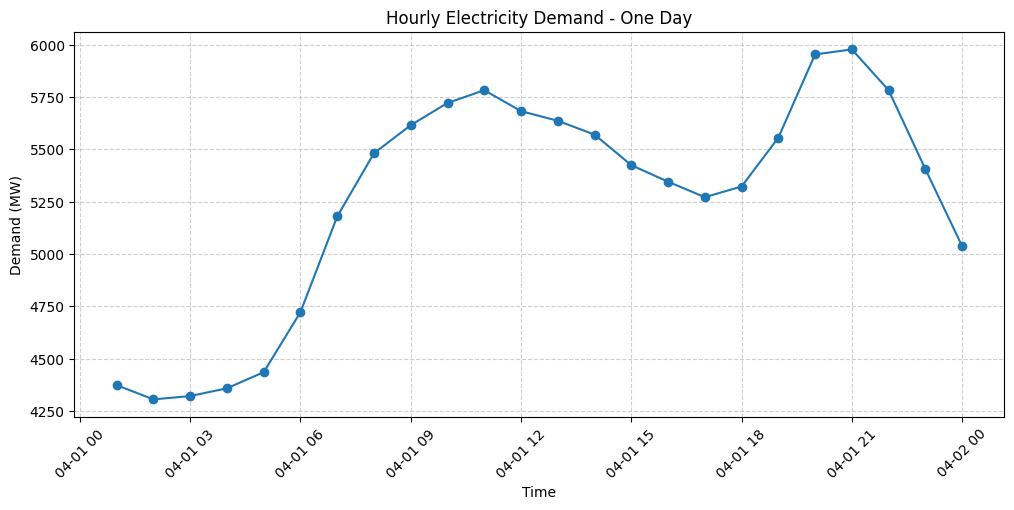

In [24]:
#Hourly electricity demand in one day
one_day = df.iloc[:24]

plt.figure(figsize=(12, 5))
plt.plot(one_day["Datetime"], one_day["PJMW_MW"], marker="o")
plt.title("Hourly Electricity Demand - One Day")
plt.xlabel("Time")
plt.ylabel("Demand (MW)")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

Early morning:
At approximately midnight/early morning, demand is around : 4,300–4,400 MW

Morning increase:
Starting around 6 AM, demand begins increasing:4,700 MW-5,700+ MW

Demand remains relatively high during the late morning and early afternoon.
It reaches approximately : 5,700–5,800 MW.

Afternoon declines,After approximately 1 PM, the demand begins declining : 5,300 MW

Evening increase:
After approximately 6 PM, demand begins rising again : 5,950 MW

Hours in a day is an important predictor for electricity demand as the demand is varying continuously according to hour of a day.

In [25]:
df["Day"] = df["Datetime"].dt.day_name()

In [26]:
print(df[["Datetime", "Day", "PJMW_MW"]].head(10))

             Datetime     Day  PJMW_MW
0 2002-04-01 01:00:00  Monday     4374
1 2002-04-01 02:00:00  Monday     4306
2 2002-04-01 03:00:00  Monday     4322
3 2002-04-01 04:00:00  Monday     4359
4 2002-04-01 05:00:00  Monday     4436
5 2002-04-01 06:00:00  Monday     4723
6 2002-04-01 07:00:00  Monday     5180
7 2002-04-01 08:00:00  Monday     5482
8 2002-04-01 09:00:00  Monday     5616
9 2002-04-01 10:00:00  Monday     5722


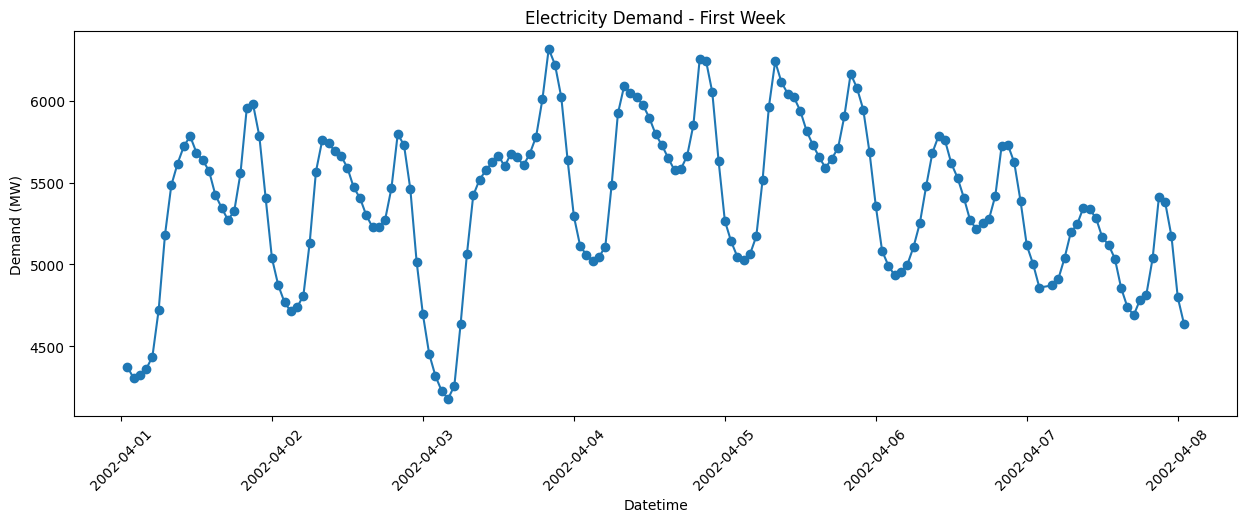

In [27]:
# Demand of electricity figured by marking them while they rise and fall in the first week
plt.figure(figsize=(15, 5))

plt.plot(df.iloc[:168]["Datetime"],df.iloc[:168]["PJMW_MW"],marker="o")
plt.title("Electricity Demand - First Week")
plt.xlabel("Datetime")
plt.ylabel("Demand (MW)")
plt.xticks(rotation=45)
plt.show()

We have to use days as referece to understand the patterns of demand of various days to predict.
Demand rises and falls repeatedly.
Each day has a peak and a low-demand period.
The peak magnitude changes from day to day.
Some days are noticeably different from others.
Therefore,this is evidence of daily seasonality plus day-of-week effects.

In [28]:
# To understand the mean of every day of the week
df.groupby("Day")["PJMW_MW"].mean()

,PJMW_MW
Day,
Friday,5686.839202
Monday,5700.518783
Saturday,5293.999413
Sunday,5149.638300
Thursday,5780.841051
Tuesday,5801.076837
Wednesday,5802.370701


In [29]:
# To understand the mean of every year's data
df.groupby(df["Datetime"].dt.year)["PJMW_MW"].mean()

,PJMW_MW
Datetime,
2002,5621.663180
2003,5700.628226
2004,5866.616602
2005,6038.406029
2006,5425.448847
2007,5635.396780
2008,5530.132544
2009,5290.557433
2010,5573.025351


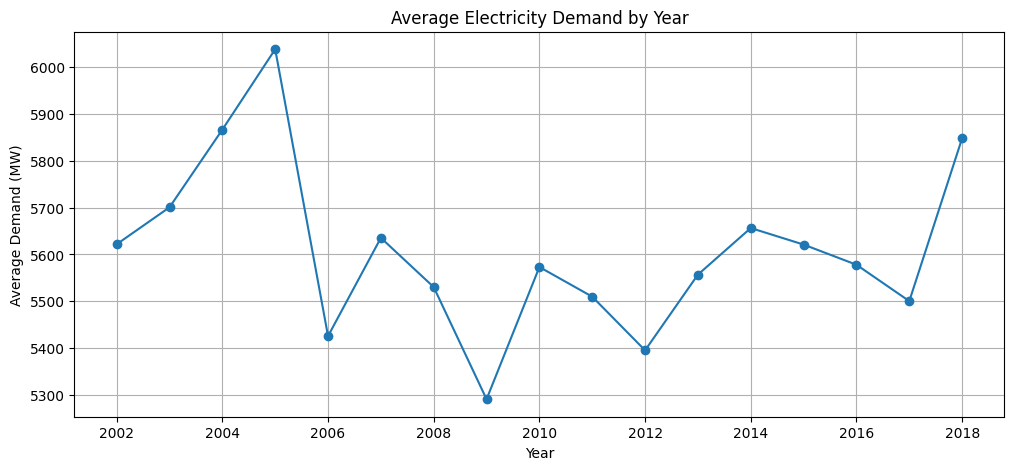

In [30]:
#average electricity demand over the years
yearly_avg = df.groupby(df["Datetime"].dt.year)["PJMW_MW"].mean()

plt.figure(figsize=(12, 5))
plt.plot(yearly_avg.index, yearly_avg.values, marker="o")
plt.title("Average Electricity Demand by Year")
plt.xlabel("Year")
plt.ylabel("Average Demand (MW)")
plt.grid(True)
plt.show()

At first it was incredibly high and then fluctuated but shows the relatively increase in demand of every year.
Electricity demand increases every year.
Instead, the model needs to learn "nonlinear changes" from historical data.

In [31]:
# To understand the data better while moving forward with better understanding(including outliers)
df["rolling_mean"] = df["PJMW_MW"].rolling(window=168).mean()
df["rolling_std"] = df["PJMW_MW"].rolling(window=168).std()

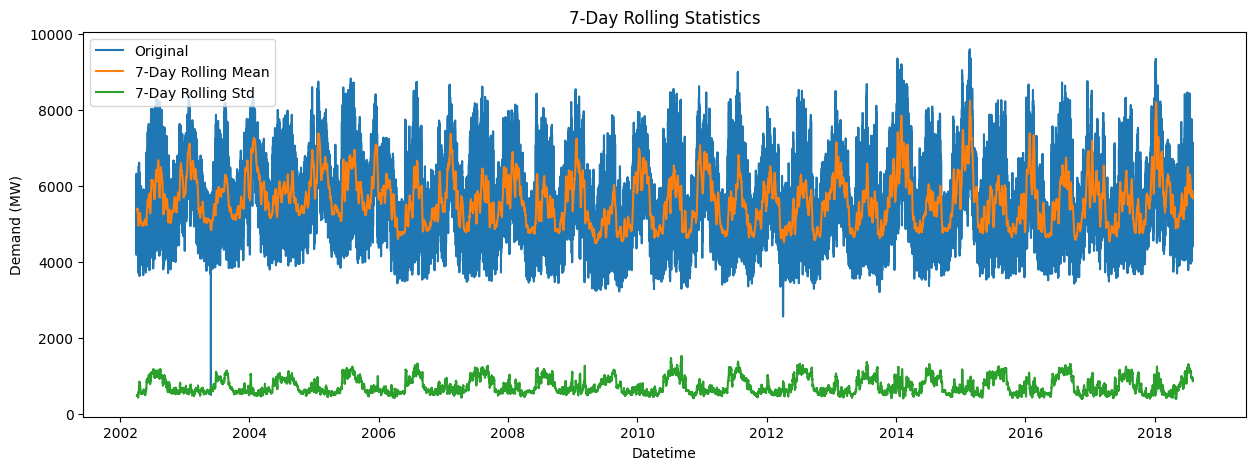

In [32]:
# 7-Days rolling statistics
plt.figure(figsize=(15, 5))

plt.plot(df["Datetime"], df["PJMW_MW"], label="Original")
plt.plot(df["Datetime"], df["rolling_mean"], label="7-Day Rolling Mean")
plt.plot(df["Datetime"], df["rolling_std"], label="7-Day Rolling Std")
plt.title("7-Day Rolling Statistics")
plt.xlabel("Datetime")
plt.ylabel("Demand (MW)")
plt.legend()
plt.show()

In [33]:
# To test the level of stationary for the given data
from statsmodels.tsa.stattools import adfuller
result = adfuller(df["PJMW_MW"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -19.88829608963819
p-value: 0.0


<Figure size 1500x500 with 0 Axes>

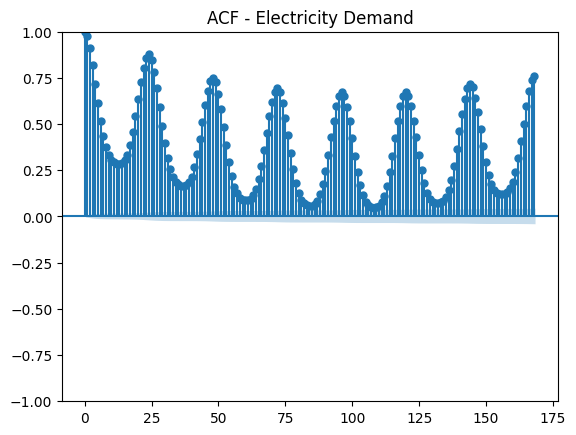

In [34]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(15, 5))
plot_acf(df["PJMW_MW"], lags=168)
plt.title("ACF - Electricity Demand")
plt.show()

ACF measures the relationship between current electricity demand and previous demand values at different time lags.

<Figure size 1500x500 with 0 Axes>

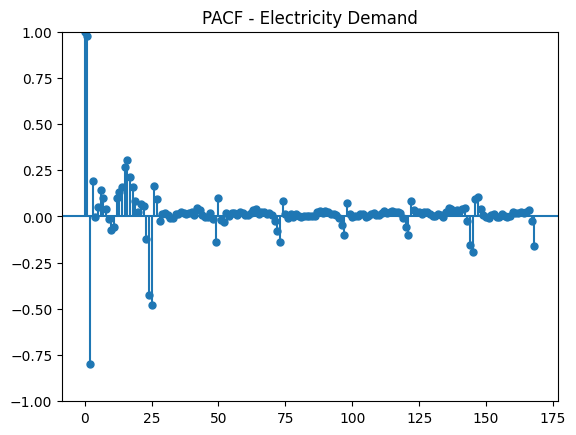

In [35]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(15, 5))
plot_pacf(df["PJMW_MW"], lags=168)
plt.title("PACF - Electricity Demand")
plt.show()

1.The PACF graph shows strong relationships at several early lags, particularly around the initial lags and periodic positions.
2.PACF attempts to identify the direct relationship between the current demand and a specific lag after accounting for relationships through intermediate lags.

In [36]:
print(df["Datetime"].min())
print(df["Datetime"].max())

2002-04-01 01:00:00
2018-08-03 00:00:00


In [37]:
pip install holidays

In [38]:
import holidays
us_holidays = holidays.US(years=range(2002, 2019))

In [39]:
# Only takes the holidays present in the dataset
holiday_dates = [
    date for date in us_holidays
    if df["Datetime"].min().date() <= date <= df["Datetime"].max().date()]

print("Number of holiday dates:", len(holiday_dates))

Number of holiday dates: 180


In [40]:
df["IsHoliday"] = df["Datetime"].dt.date.isin(holiday_dates).astype(int)

In [41]:
print(df.groupby("IsHoliday")["PJMW_MW"].mean())

IsHoliday
0    5606.281886
1    5476.773380
Name: PJMW_MW, dtype: float64


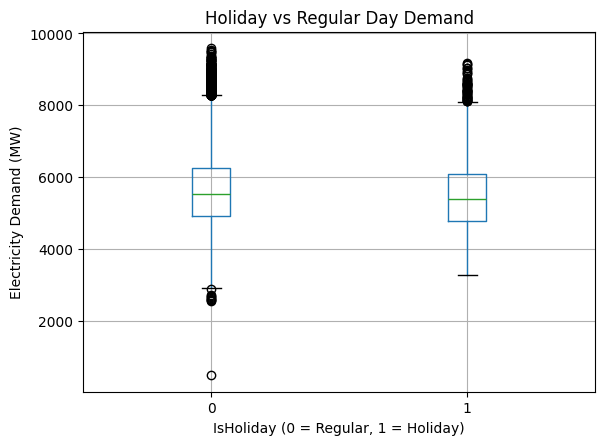

In [42]:
# Demand on holidays vs regular days
df.boxplot(column="PJMW_MW", by="IsHoliday")

plt.title("Holiday vs Regular Day Demand")
plt.suptitle("")
plt.xlabel("IsHoliday (0 = Regular, 1 = Holiday)")
plt.ylabel("Electricity Demand (MW)")
plt.show()

Holiday demand is generally lower than regular-day demand, so IsHoliday can potentially help the forecasting mode.
Holiday vs Regular Day:
1.Holiday days show slightly lower average electricity demand than regular days,
2.indicating that holidays have a noticeable effect on electricity consumption.

In [43]:
# Mean of every months
monthly_demand = df.groupby(df["Datetime"].dt.month)["PJMW_MW"].mean()
print(monthly_demand)

Datetime
1     6447.667759
2     6296.808813
3     5654.097376
4     5022.310855
5     5015.845746
6     5516.756046
7     5861.537081
8     5822.142809
9     5205.872049
10    4997.642155
11    5403.630372
12    6064.431236
Name: PJMW_MW, dtype: float64


Demand is not constant throughout the year.
1.We see higher demand around:
Winter: December–February
Summer: July–August
2.And lower demand around:
Spring: April–May
Autumn: September–October

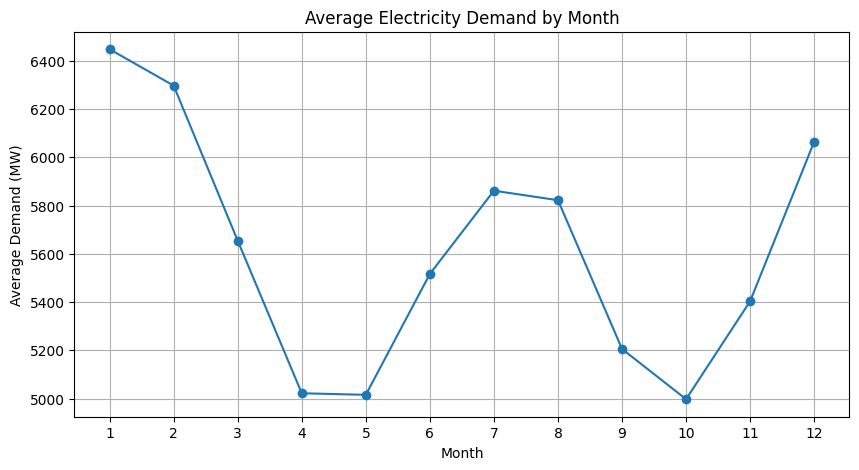

In [44]:
# Average demand of electricity in every months
plt.figure(figsize=(10, 5))

monthly_demand.plot(marker="o")
plt.title("Average Electricity Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Demand (MW)")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

Average Electricity Demand by Month:
1.Electricity demand varies across months, showing clear monthly/seasonal seasonality.
2.Demand is generally higher during winter and summer months and lower during spring/autumn.

In [45]:
df['Month'] = df['Datetime'].dt.month

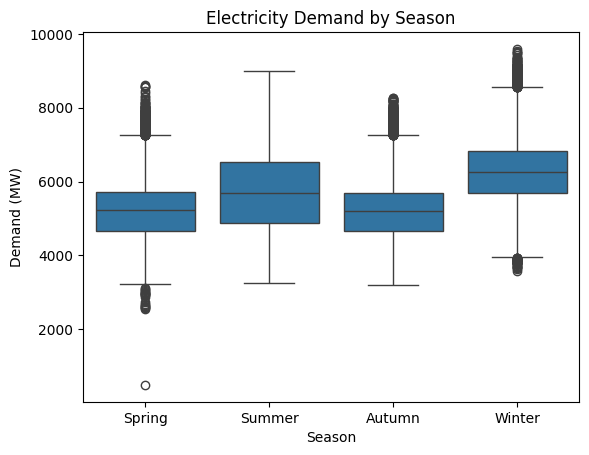

In [46]:
# Demand based on every respective seasons
def get_season(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    else:
        return 'Winter'

df['Season'] = df['Month'].apply(get_season)
sns.boxplot(x='Season', y='PJMW_MW', data=df)
plt.title('Electricity Demand by Season')
plt.xlabel('Season')
plt.ylabel('Demand (MW)')
plt.show()

Electricity Demand by Season:
1.Winter has the highest demand distribution.
2.Summer is also relatively high and shows greater spread/variability.
3.Spring and Autumn have lower demand, with generally tighter distributions.
4.There is considerable overlap between seasons, but the seasonal shift in demand level is clearly visible.
5.The many points beyond the whiskers indicate extreme demand observations, which matches our IQR outlier analysis.

In [47]:
# Outlier capping
Q1 = df['PJMW_MW'].quantile(0.25)
Q3 = df['PJMW_MW'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['PJMW_MW'] < lower_bound) | (df['PJMW_MW'] > upper_bound)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of outliers:", len(outliers))

Q1: 4907.0
Q3: 6252.0
IQR: 1345.0
Lower Bound: 2889.5
Upper Bound: 8269.5
Number of outliers: 703


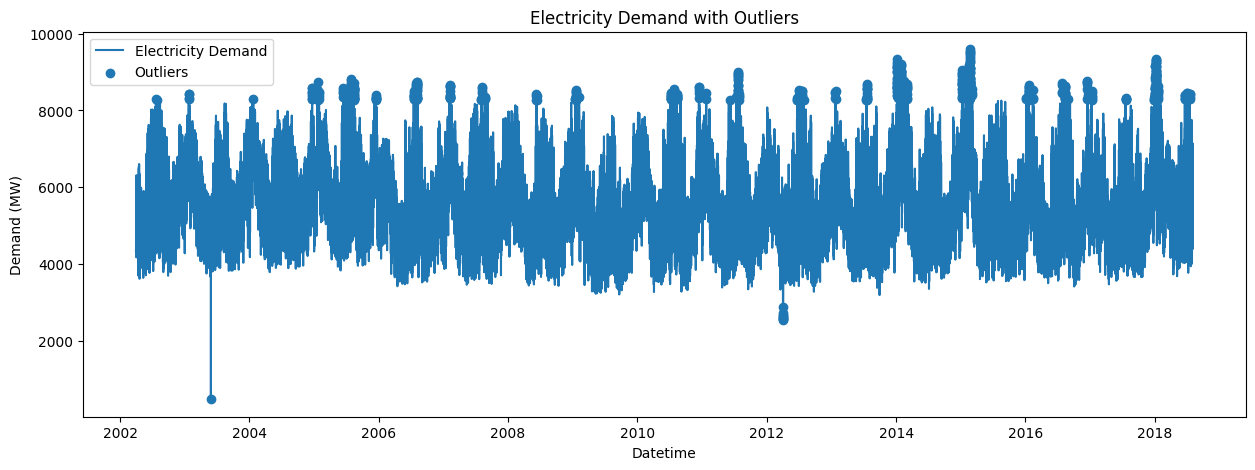

In [48]:
# Calculate IQR bounds
Q1 = df['PJMW_MW'].quantile(0.25)
Q3 = df['PJMW_MW'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Identify outliers
outliers = df[(df['PJMW_MW'] < lower_bound) | (df['PJMW_MW'] > upper_bound)]

# Plot demand with outliers over the years
plt.figure(figsize=(15, 5))
plt.plot(
    df['Datetime'],
    df['PJMW_MW'],
    label='Electricity Demand')

plt.scatter(
    outliers['Datetime'],
    outliers['PJMW_MW'],
    label='Outliers')

plt.title('Electricity Demand with Outliers')
plt.xlabel('Datetime')
plt.ylabel('Demand (MW)')
plt.legend()
plt.show()

1.The graph contains many high-demand points marked as outliers.
2.They occur repeatedly around different years.
3.This is important because these are not necessarily errors.
4.For example, high demand may be a genuine extreme-demand event.
There are also very low observations, including the extremely low value around 2003.

In [49]:
# Labelling data with various parameters for better understanding and prediction
df["Hour"] = df["Datetime"].dt.hour
df["Day"] = df["Datetime"].dt.day
df["DayOfWeek"] = df["Datetime"].dt.dayofweek
df["Month"] = df["Datetime"].dt.month
df["Year"] = df["Datetime"].dt.year
df["IsWeekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)
df.head()

,Datetime,PJMW_MW,Day,rolling_mean,rolling_std,IsHoliday,Month,Season,Hour,DayOfWeek,Year,IsWeekend
0,2002-04-01 01:00:00,4374,1,NaN,NaN,0,4,Spring,1,0,2002,0
1,2002-04-01 02:00:00,4306,1,NaN,NaN,0,4,Spring,2,0,2002,0
2,2002-04-01 03:00:00,4322,1,NaN,NaN,0,4,Spring,3,0,2002,0
3,2002-04-01 04:00:00,4359,1,NaN,NaN,0,4,Spring,4,0,2002,0
4,2002-04-01 05:00:00,4436,1,NaN,NaN,0,4,Spring,5,0,2002,0


In [50]:
# Using lags for better understanding,prediction and dependencies using past data
df["lag_1"] = df["PJMW_MW"].shift(1)
df["lag_2"] = df["PJMW_MW"].shift(2)
df["lag_3"] = df["PJMW_MW"].shift(3)

df["lag_24"] = df["PJMW_MW"].shift(24)
df["lag_48"] = df["PJMW_MW"].shift(48)

df["lag_168"] = df["PJMW_MW"].shift(168)

In [51]:
df[["Datetime", "PJMW_MW", "lag_1", "lag_24", "lag_168"]].head(30)

,Datetime,PJMW_MW,lag_1,lag_24,lag_168
0,2002-04-01 01:00:00,4374,NaN,NaN,NaN
1,2002-04-01 02:00:00,4306,4374.0,NaN,NaN
2,2002-04-01 03:00:00,4322,4306.0,NaN,NaN
3,2002-04-01 04:00:00,4359,4322.0,NaN,NaN
4,2002-04-01 05:00:00,4436,4359.0,NaN,NaN
5,2002-04-01 06:00:00,4723,4436.0,NaN,NaN
6,2002-04-01 07:00:00,5180,4723.0,NaN,NaN
7,2002-04-01 08:00:00,5482,5180.0,NaN,NaN
8,2002-04-01 09:00:00,5616,5482.0,NaN,NaN
9,2002-04-01 10:00:00,5722,5616.0,NaN,NaN


In [52]:
df["rolling_mean_24"] = df["PJMW_MW"].shift(1).rolling(24).mean()
df["rolling_mean_168"] = df["PJMW_MW"].shift(1).rolling(168).mean()
df["rolling_std_24"] = df["PJMW_MW"].shift(1).rolling(24).std()

In [53]:
df[["Datetime","PJMW_MW","rolling_mean_24","rolling_mean_168","rolling_std_24"]].head(200)

,Datetime,PJMW_MW,rolling_mean_24,rolling_mean_168,rolling_std_24
0,2002-04-01 01:00:00,4374,NaN,NaN,NaN
1,2002-04-01 02:00:00,4306,NaN,NaN,NaN
2,2002-04-01 03:00:00,4322,NaN,NaN,NaN
3,2002-04-01 04:00:00,4359,NaN,NaN,NaN
4,2002-04-01 05:00:00,4436,NaN,NaN,NaN
...,...,...,...,...,...
195,2002-04-09 05:00:00,4280,5239.625000,5371.375000,537.455423
196,2002-04-09 06:00:00,4577,5224.625000,5368.654762,559.490126
197,2002-04-09 07:00:00,5144,5209.500000,5367.273810,572.279500
198,2002-04-09 08:00:00,5374,5193.500000,5367.351190,568.342059


In [54]:
df = df.drop(columns=["rolling_mean", "rolling_std"])

In [55]:
df = df.dropna().reset_index(drop=True)

In [56]:
print(df.isnull().sum())
print(df.shape)

Datetime            0
PJMW_MW             0
Day                 0
IsHoliday           0
Month               0
Season              0
Hour                0
DayOfWeek           0
Year                0
IsWeekend           0
lag_1               0
lag_2               0
lag_3               0
lag_24              0
lag_48              0
lag_168             0
rolling_mean_24     0
rolling_mean_168    0
rolling_std_24      0
dtype: int64
(143038, 19)


In [57]:
print(df.columns)

Index(['Datetime', 'PJMW_MW', 'Day', 'IsHoliday', 'Month', 'Season', 'Hour',
       'DayOfWeek', 'Year', 'IsWeekend', 'lag_1', 'lag_2', 'lag_3', 'lag_24',
       'lag_48', 'lag_168', 'rolling_mean_24', 'rolling_mean_168',
       'rolling_std_24'],
      dtype='object')


In [58]:
df

,Datetime,PJMW_MW,Day,IsHoliday,Month,Season,Hour,DayOfWeek,Year,IsWeekend,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168,rolling_mean_24,rolling_mean_168,rolling_std_24
0,2002-04-08 02:00:00,4532,8,0,4,Spring,2,0,2002,0,4634.0,4798.0,5171.0,5002.0,5082.0,4374.0,5029.625000,5379.339286,234.430264
1,2002-04-08 03:00:00,4481,8,0,4,Spring,3,0,2002,0,4532.0,4634.0,4798.0,4858.0,4992.0,4306.0,5010.041667,5380.279762,255.520522
2,2002-04-08 04:00:00,4527,8,0,4,Spring,4,0,2002,0,4481.0,4532.0,4634.0,4871.0,4932.0,4322.0,4994.333333,5381.321429,276.038225
3,2002-04-08 05:00:00,4640,8,0,4,Spring,5,0,2002,0,4527.0,4481.0,4532.0,4909.0,4956.0,4359.0,4980.000000,5382.541667,291.233658
4,2002-04-08 06:00:00,4940,8,0,4,Spring,6,0,2002,0,4640.0,4527.0,4481.0,5038.0,4997.0,4436.0,4968.791667,5384.214286,299.153586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143033,2018-08-02 20:00:00,6545,2,0,8,Summer,20,3,2018,0,6693.0,6758.0,6708.0,6816.0,6276.0,7354.0,5820.541667,5681.827381,775.289117
143034,2018-08-02 21:00:00,6496,2,0,8,Summer,21,3,2018,0,6545.0,6693.0,6758.0,6571.0,6250.0,7063.0,5809.250000,5677.011905,762.020384
143035,2018-08-02 22:00:00,6325,2,0,8,Summer,22,3,2018,0,6496.0,6545.0,6693.0,6362.0,6123.0,6895.0,5806.125000,5673.636905,758.908101
143036,2018-08-02 23:00:00,5892,2,0,8,Summer,23,3,2018,0,6325.0,6496.0,6545.0,5881.0,5771.0,6255.0,5804.583333,5670.244048,757.766507


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143038 entries, 0 to 143037
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Datetime          143038 non-null  datetime64[ns]
 1   PJMW_MW           143038 non-null  int64         
 2   Day               143038 non-null  int32         
 3   IsHoliday         143038 non-null  int64         
 4   Month             143038 non-null  int32         
 5   Season            143038 non-null  object        
 6   Hour              143038 non-null  int32         
 7   DayOfWeek         143038 non-null  int32         
 8   Year              143038 non-null  int32         
 9   IsWeekend         143038 non-null  int64         
 10  lag_1             143038 non-null  float64       
 11  lag_2             143038 non-null  float64       
 12  lag_3             143038 non-null  float64       
 13  lag_24            143038 non-null  float64       
 14  lag_

   MODEL BUILDING AND MODEL EVALUATION

In [63]:
# Arranging data in a proper order and splitting it into train and test split
df = df.sort_values("Datetime").reset_index(drop=True)

last_date = df["Datetime"].max()

test_start = last_date - pd.DateOffset(years=1)

train_df = df[df["Datetime"] < test_start].copy()
test_df = df[df["Datetime"] >= test_start].copy()

print("Training period:")
print(train_df["Datetime"].min(), "to", train_df["Datetime"].max())

print("\nTesting period:")
print(test_df["Datetime"].min(), "to", test_df["Datetime"].max())

print("\nTrain rows:", len(train_df))
print("Test rows :", len(test_df))

Training period:
2002-04-08 02:00:00 to 2017-08-02 23:00:00

Testing period:
2017-08-03 00:00:00 to 2018-08-03 00:00:00

Train rows: 134277
Test rows : 8761


In [64]:
# Prepare Random Forest and XGBoost datasets
feature_cols=[
    "Hour",
    "Day",
    "DayOfWeek",
    "Month",
    "Year",
    "IsWeekend",
    "IsHoliday",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_24",
    "lag_48",
    "lag_168",
    "rolling_mean_24",
    "rolling_mean_168",
    "rolling_std_24"
]

X_train = train_df[feature_cols]
y_train = train_df["PJMW_MW"]

X_test = test_df[feature_cols]
y_test = test_df["PJMW_MW"]

print(X_train.shape)
print(X_test.shape)

(134277, 16)
(8761, 16)


EVALUATION FUNCTION

In [65]:
#Before training models, create one common evaluation function.
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
import pandas as pd

def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

    r2 = r2_score(y_true, y_pred)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2
    }
results = []

MODEL-1 : ARIMA-TIMESERIES TRADITIONAL ALGORITHM

In [66]:
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Prepare the time-series data
train_series = train_df["PJMW_MW"].astype(float).reset_index(drop=True)
test_series = test_df["PJMW_MW"].astype(float).reset_index(drop=True)

# order = (p, d, q)
# p = 1
# d = 1
# q = 1
arima_model = ARIMA(
    train_series,
    order=(5,1,1)
)

# Fit model
arima_fit = arima_model.fit()


# Forecast

arima_pred = arima_fit.forecast(
    steps=len(test_series)
)

# Convert predictions to NumPy array
arima_pred = arima_pred.to_numpy()


# Evaluate
arima_result = evaluate_model(
    "ARIMA",
    test_series.to_numpy(),
    arima_pred
)

# Add result
results.append(arima_result)

# Display result
arima_result

{'Model': 'ARIMA',
 'MAE': 942.014326368379,
 'RMSE': np.float64(1131.3492264914207),
 'MAPE': np.float64(18.182753349345035),
 'R2': -0.2962130787436643}

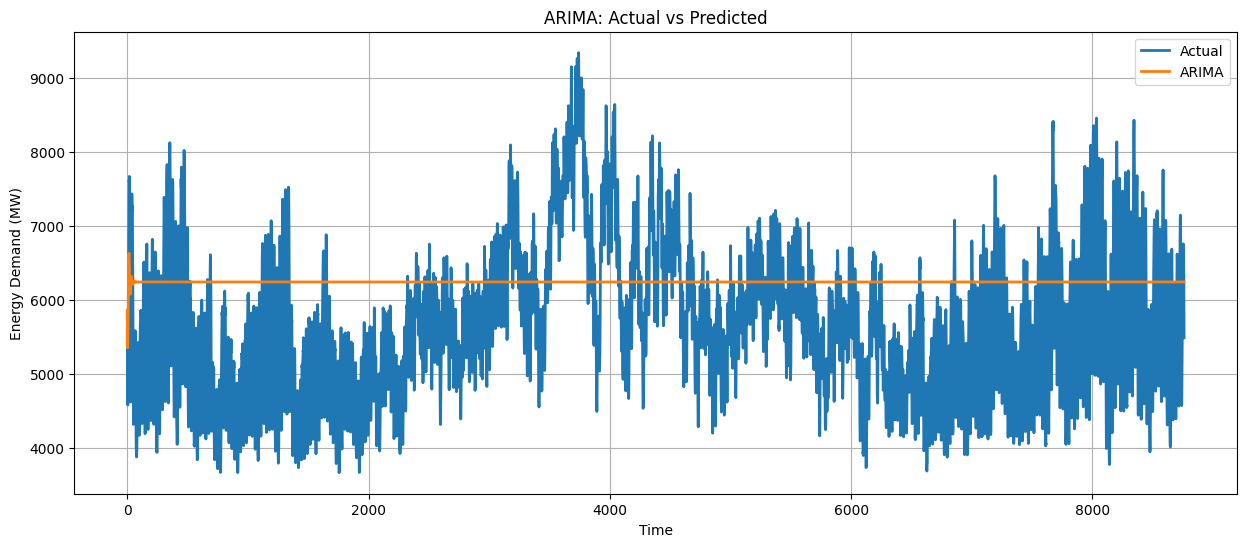

In [67]:
#Plot actual vs predicted
plt.figure(figsize=(15, 6))

plt.plot(
    test_series.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    arima_pred,
    label="ARIMA",
    linewidth=2
)

plt.title("ARIMA: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Energy Demand (MW)")
plt.legend()
plt.grid(True)
plt.show()

MODEL-2 : SARIMAX-TIMESERIES

In [68]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Take only the last 8 years of hourly training data
train_series_8y = train_series.iloc[-70080:]

print("Training observations:", len(train_series_8y))
start_date = train_df.iloc[train_series_8y.index.min()]['Datetime']
end_date = train_df.iloc[train_series_8y.index.max()]['Datetime']

print("Start Date:", start_date.strftime("%Y-%m-%d"))
print("End Date:", end_date.strftime("%Y-%m-%d"))

# Build SARIMAX model
sarimax_model = SARIMAX(
    train_series_8y,
    order=(1,1,2),
    seasonal_order=(1,1,0,24),
    enforce_stationarity=False,
    enforce_invertibility=False,
    simple_differencing=True
)

# Fit model
sarimax_fit = sarimax_model.fit(
    disp=False,
    maxiter=50
)

# Forecast
sarimax_pred = sarimax_fit.forecast(
    steps=len(test_series)
)

# Evaluation
sarimax_result = evaluate_model(
    "SARIMAX (8 Years)",
    test_series.values,
    sarimax_pred.values
)

results.append(sarimax_result)

Training observations: 70080
Start Date: 2009-08-04
End Date: 2017-08-02


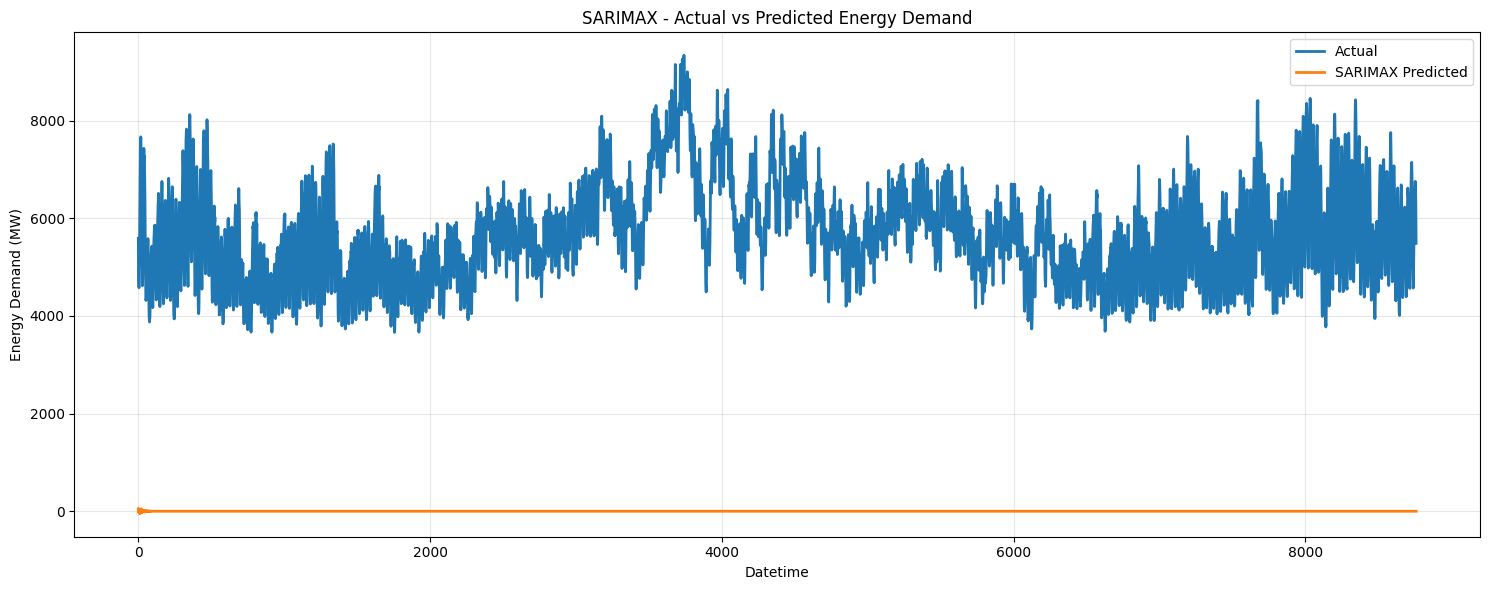

In [69]:
#Plot actual vs predicted
plt.figure(figsize=(15, 6))

plt.plot(
    test_series.index,
    test_series.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    test_series.index,
    sarimax_pred.values,
    label="SARIMAX Predicted",
    linewidth=2
)

plt.title("SARIMAX - Actual vs Predicted Energy Demand")
plt.xlabel("Datetime")
plt.ylabel("Energy Demand (MW)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

MODEL-3 : RANDOM FOREST

In [70]:
#Training and evaluating random forest model
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

#Predict
rf_pred = rf_model.predict(X_test)

#Evaluate
rf_result = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

results.append(rf_result)

rf_result

{'Model': 'Random Forest',
 'MAE': 55.32774369409104,
 'RMSE': np.float64(73.28986062107565),
 'MAPE': np.float64(0.9708186692186541),
 'R2': 0.9945603516893324}

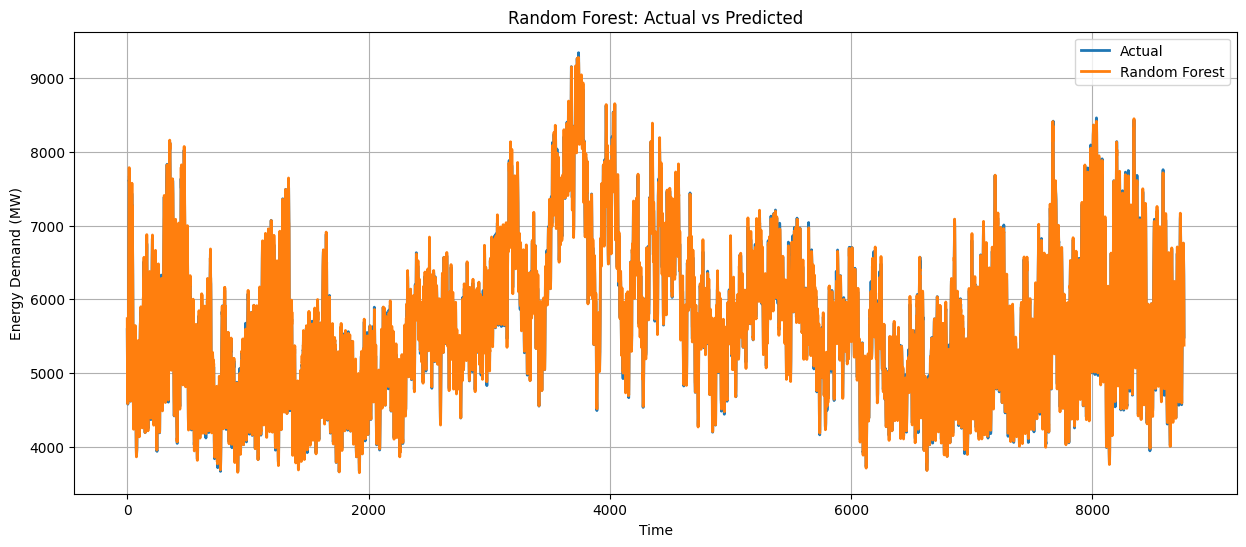

In [71]:
#Plot actual vs predicted
plt.figure(figsize=(15, 6))

plt.plot(
    y_test.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    rf_pred,
    label="Random Forest",
    linewidth=2
)

plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Energy Demand (MW)")
plt.legend()
plt.grid(True)
plt.show()

MODEL-4 : XGBOOST

In [72]:
from xgboost import XGBRegressor

#Train
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

#Predict
xgb_pred = xgb_model.predict(X_test)

#Evaluate
xgb_result = evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred
)

results.append(xgb_result)

xgb_result

{'Model': 'XGBoost',
 'MAE': 52.94877243041992,
 'RMSE': np.float64(70.879515811825),
 'MAPE': np.float64(0.9206868022808398),
 'R2': 0.9949122667312622}

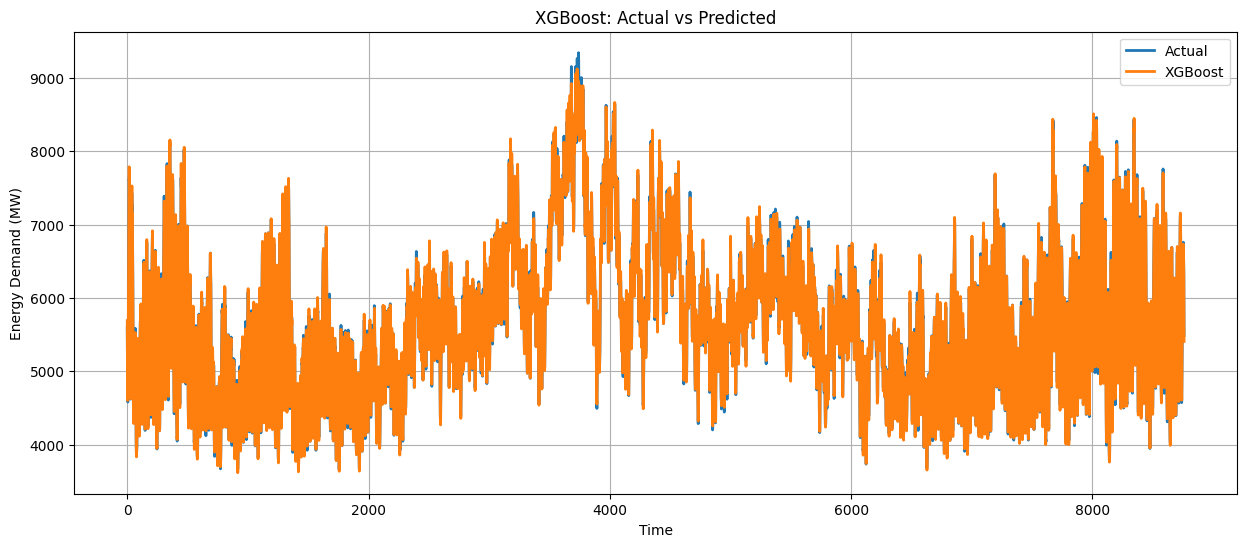

In [73]:
#Plot actual vs predicted
plt.figure(figsize=(15, 6))

plt.plot(
    y_test.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    xgb_pred,
    label="XGBoost",
    linewidth=2
)

plt.title("XGBoost: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Energy Demand (MW)")
plt.legend()
plt.grid(True)
plt.show()

In [75]:
train_series = train_df.set_index("Datetime")["PJMW_MW"]
test_series = test_df.set_index("Datetime")["PJMW_MW"]

MODEL-5 : LSTM

In [77]:
# importing necessary libraries for this certain model
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [78]:
#LSTM preprocessing
scaler = MinMaxScaler()

train_values = train_df["PJMW_MW"].values.reshape(-1, 1)

scaled_train = scaler.fit_transform(
    train_values
)
LOOKBACK = 168

#Function:
def create_sequences(data, lookback):

    X = []
    y = []

    for i in range(lookback, len(data)):

        X.append(
            data[i-lookback:i, 0]
        )

        y.append(
            data[i, 0]
        )

    X = np.array(X)
    y = np.array(y)

    return X, y

X_lstm_train, y_lstm_train = create_sequences(
    scaled_train,
    LOOKBACK
)

X_lstm_train = X_lstm_train.reshape(
    X_lstm_train.shape[0],
    X_lstm_train.shape[1],
    1
)

In [79]:
#Build the LSTM
lstm_model = Sequential([
    LSTM(32, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(16),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_lstm_train,
    y_lstm_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    shuffle=False
)

Epoch 1/20
943/943 ━━━━━━━━━━━━━━━━━━━━ 218s 227ms/step - loss: 0.0142 - val_loss: 0.0045
Epoch 2/20
943/943 ━━━━━━━━━━━━━━━━━━━━ 197s 208ms/step - loss: 0.0063 - val_loss: 0.0017
Epoch 3/20
943/943 ━━━━━━━━━━━━━━━━━━━━ 154s 157ms/step - loss: 0.0033 - val_loss: 8.3004e-04
Epoch 4/20
943/943 ━━━━━━━━━━━━━━━━━━━━ 200s 155ms/step - loss: 0.0016 - val_loss: 5.6181e-04
Epoch 5/20
943/943 ━━━━━━━━━━━━━━━━━━━━ 203s 156ms/step - loss: 9.4482e-04 - val_loss: 4.0492e-04
Epoch 6/20
943/943 ━━━━━━━━━━━━━━━━━━━━ 147s 156ms/step - loss: 6.6353e-04 - val_loss: 2.9937e-04
Epoch 7/20
943/943 ━━━━━━━━━━━━━━━━━━━━ 147s 156ms/step - loss: 5.3430e-04 - val_loss: 2.4213e-04
Epoch 8/20
943/943 ━━━━━━━━━━━━━━━━━━━━ 146s 155ms/step - loss: 4.6580e-04 - val_loss: 2.0728e-04
Epoch 9/20
943/943 ━━━━━━━━━━━━━━━━━━━━ 148s 157ms/step - loss: 4.2825e-04 - val_loss: 1.9616e-04
Epoch 10/20
943/943 ━━━━━━━━━━━━━━━━━━━━ 202s 156ms/step - loss: 4.0089e-04 - val_loss: 1.8532e-04
Epoch 11/20
943/943 ━━━━━━━━━━━━━━━━━━━━ 20

In [80]:
#LSTM test prediction
combined = pd.concat([
    train_df[["Datetime", "PJMW_MW"]],
    test_df[["Datetime", "PJMW_MW"]]
])

combined_values = combined["PJMW_MW"].values.reshape(-1, 1)

combined_scaled = scaler.transform(
    combined_values
)

In [81]:
test_start_index = len(train_df)
lstm_inputs = combined_scaled[
    test_start_index - LOOKBACK:
]

X_lstm_test = []

for i in range(
    LOOKBACK,
    len(lstm_inputs)
):
    X_lstm_test.append(
        lstm_inputs[i-LOOKBACK:i, 0]
    )

X_lstm_test = np.array(X_lstm_test)

X_lstm_test = X_lstm_test.reshape(
    X_lstm_test.shape[0],
    X_lstm_test.shape[1],
    1
)

# Predict
lstm_pred_scaled = lstm_model.predict(
    X_lstm_test
)

# Convert back: inverse the scaling to get MW units
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()

# Evaluate
lstm_result = evaluate_model(
    "LSTM",
    test_df["PJMW_MW"].values,
    lstm_pred
)

results.append(lstm_result)

lstm_result

274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step


{'Model': 'LSTM',
 'MAE': 80.63280487060547,
 'RMSE': np.float64(102.46708694136863),
 'MAPE': np.float64(1.4317649621617587),
 'R2': 0.9893671274185181}

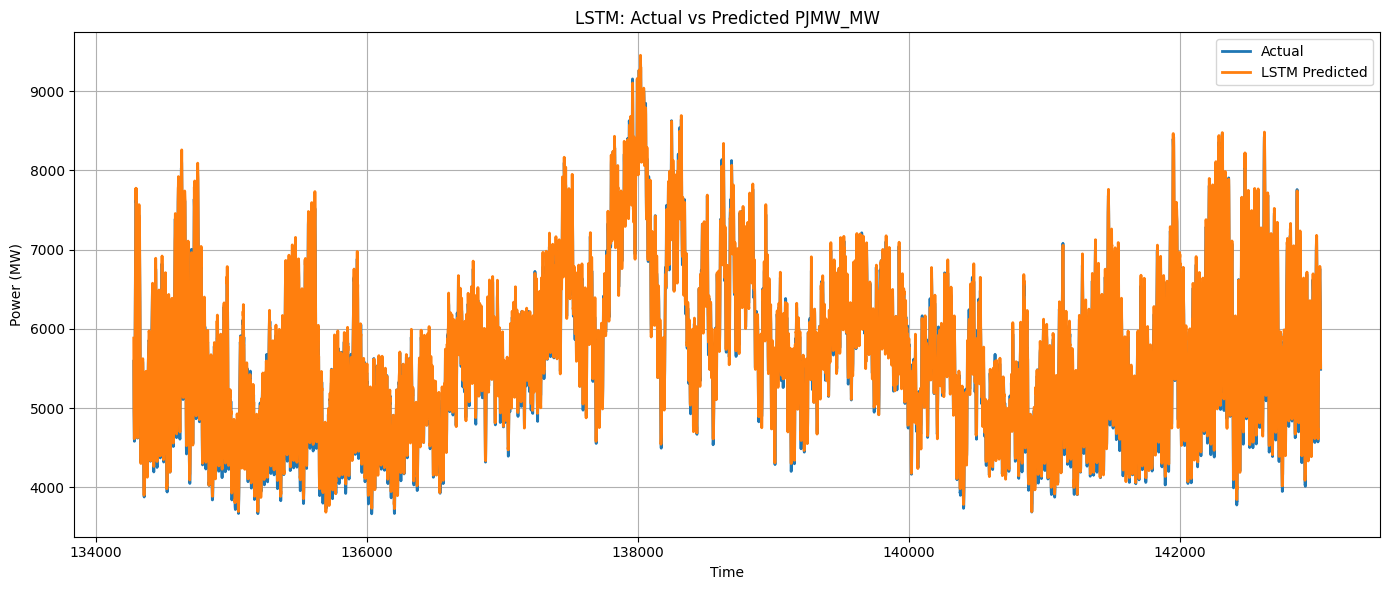

In [82]:
#Plot actual vs predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    test_df.index,
    test_df["PJMW_MW"].values,
    label="Actual",
    linewidth=2
)

plt.plot(
    test_df.index,
    lstm_pred,
    label="LSTM Predicted",
    linewidth=2
)

plt.title("LSTM: Actual vs Predicted PJMW_MW")
plt.xlabel("Time")
plt.ylabel("Power (MW)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

 COMPARING ALL MODELS AND THIER PERFORMANCE'S

 EVALUATING THE MODEL CONSIDERING EVERY METRICS - FOR BEST FIT SELECTION

In [83]:
#Create final model's comparison
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="RMSE"
).reset_index(drop=True)

results_df

,Model,MAE,RMSE,MAPE,R2
0,XGBoost,52.948772,70.879516,0.920687,0.994912
1,Random Forest,55.327744,73.289861,0.970819,0.994560
2,LSTM,80.632805,102.467087,1.431765,0.989367
3,ARIMA,942.014326,1131.349226,18.182753,-0.296213
4,SARIMAX (8 Years),5700.816113,5786.774482,99.999820,-32.912214


KEY FINDINGS :

1.XGBoost — Best overall: It has the lowest MAE (52.95), RMSE (70.88), and MAPE (0.92%), while also achieving the highest R2 (0.9949). Therefore, it provides the strongest overall prediction performance.

2.Random Forest — Strong second: Its MAE (55.33), RMSE (73.29), and MAPE (0.97%) are slightly higher than XGBoost, with an R2 of 0.9946. Its performance is very close to XGBoost.

3.LSTM — Moderate performance: LSTM achieves an R2 of 0.9894, but its errors are higher: MAE 80.63, RMSE 102.47, and MAPE 1.43%. It predicts reasonably well but is less accurate than the tree-based models for this dataset.

4.ARIMA — Poor performance: MAE 942.01, RMSE 1131.35, and MAPE 18.18% are substantially higher, while R2 is -0.2962. The negative R² indicates that its predictions perform poorly relative to a simple baseline.

5.SARIMAX (8 Years) — Weakest model: It has extremely high MAE (5700.82), RMSE (5786.77), MAPE (100%) and a very negative R2 (-32.91), indicating very poor predictive performance on this test set.

Overall conclusion :

XGBoost should be selected as the overall prediction model based on the supplied metrics, because it simultaneously minimizes all three error metrics and maximizes R2. Random Forest is a very close alternative, while LSTM performs reasonably but with higher prediction errors. ARIMA and SARIMAX show substantially weaker performance on this dataset.

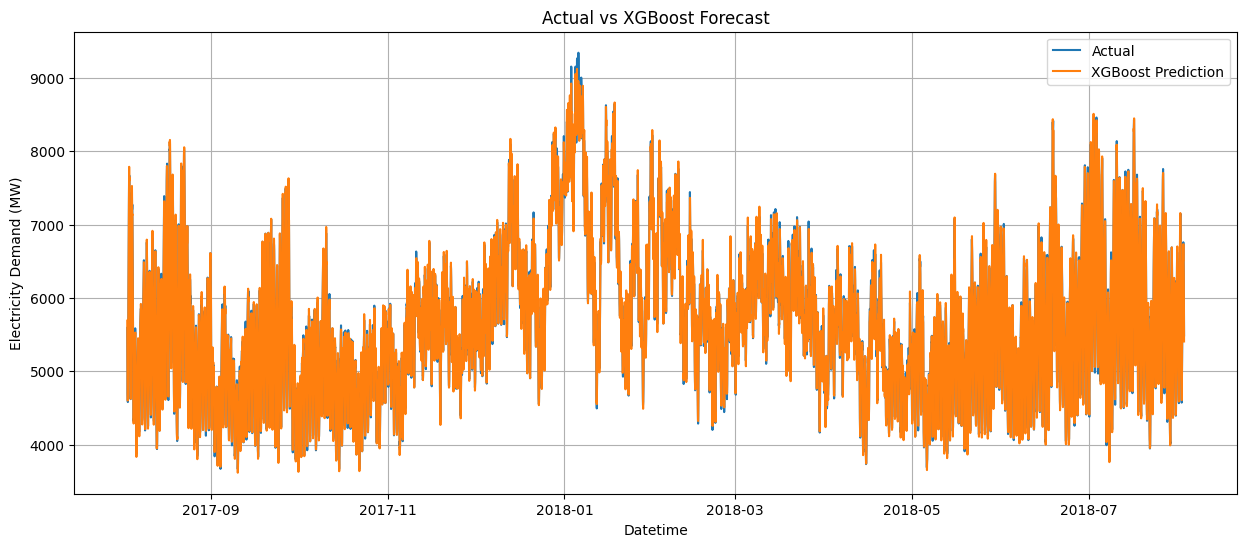

In [84]:
# Best Model's Plot actual vs predicted
plt.figure(figsize=(15, 6))

plt.plot(
    test_df["Datetime"],
    y_test,
    label="Actual"
)

plt.plot(
    test_df["Datetime"],
    xgb_pred,
    label="XGBoost Prediction"
)

plt.xlabel("Datetime")
plt.ylabel("Electricity Demand (MW)")
plt.title("Actual vs XGBoost Forecast")

plt.legend()
plt.grid(True)

plt.show()

In [85]:
best_pred = xgb_pred

In [86]:
residuals = y_test.values - best_pred

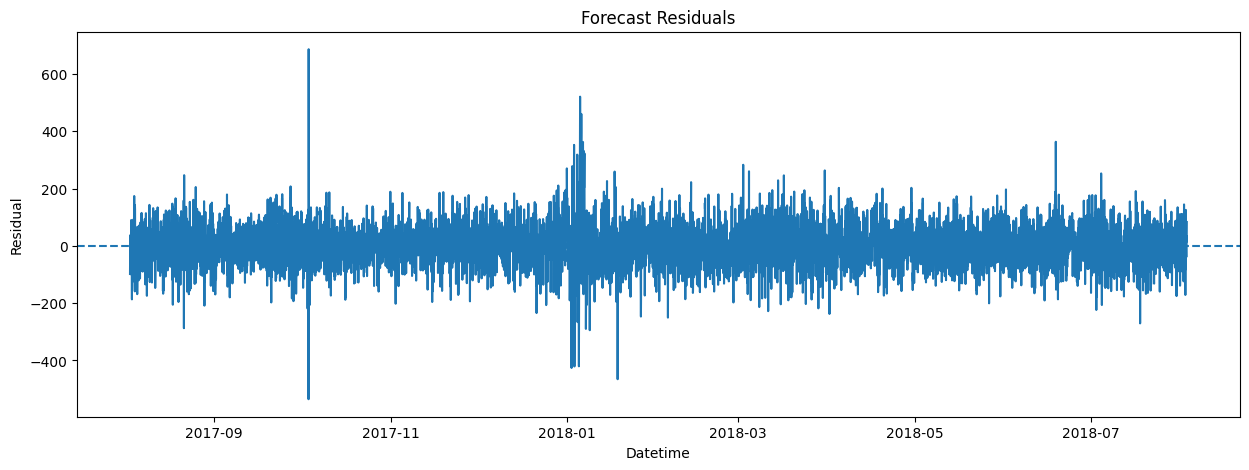

In [87]:
# Forecasting residuals
plt.figure(figsize=(15,5))

plt.plot(
    test_df["Datetime"],
    residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Forecast Residuals")
plt.xlabel("Datetime")
plt.ylabel("Residual")

plt.show()

In [88]:
#Feature importance for XGBoost
importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
7,lag_1,0.405675
8,lag_2,0.322448
10,lag_24,0.154065
9,lag_3,0.032692
0,Hour,0.023677
12,lag_168,0.022043
2,DayOfWeek,0.013238
5,IsWeekend,0.010285
13,rolling_mean_24,0.007053
15,rolling_std_24,0.003330


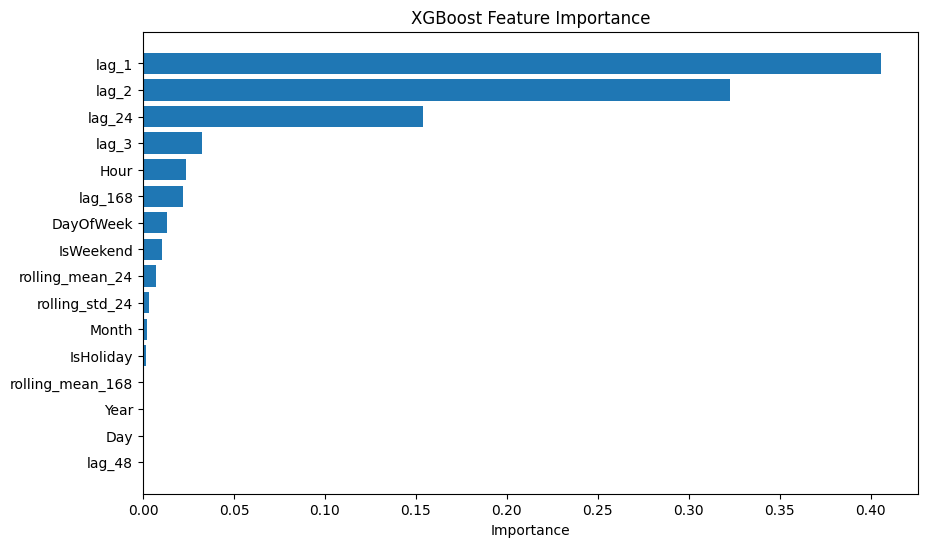

In [89]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")

plt.show()

In [90]:
#30-day recursive forecast for XGBoost
history_df = df.copy()

history_df = history_df.sort_values(
    "Datetime"
).reset_index(drop=True)

In [91]:
#Create a function to calculate features for one timestamp :
def create_future_features(history):

    row = {}

    current_time = history["Datetime"].iloc[-1] + pd.Timedelta(hours=1)

    row["Hour"] = current_time.hour
    row["Day"] = current_time.day
    row["DayOfWeek"] = current_time.dayofweek
    row["Month"] = current_time.month
    row["Year"] = current_time.year
    row["IsWeekend"] = int(
        current_time.dayofweek in [5, 6]
    )

    row["IsHoliday"] = int(
        current_time.date() in holiday_dates
    )

    row["lag_1"] = history["PJMW_MW"].iloc[-1]
    row["lag_2"] = history["PJMW_MW"].iloc[-2]
    row["lag_3"] = history["PJMW_MW"].iloc[-3]

    row["lag_24"] = history["PJMW_MW"].iloc[-24]
    row["lag_48"] = history["PJMW_MW"].iloc[-48]
    row["lag_168"] = history["PJMW_MW"].iloc[-168]

    row["rolling_mean_24"] = (
        history["PJMW_MW"]
        .iloc[-24:]
        .mean()
    )

    row["rolling_mean_168"] = (
        history["PJMW_MW"]
        .iloc[-168:]
        .mean()
    )

    row["rolling_std_24"] = (
        history["PJMW_MW"]
        .iloc[-24:]
        .std()
    )

    return pd.DataFrame([row]), current_time

In [92]:
# Predict the future demands
future_predictions = []

future_history = history_df[
    ["Datetime", "PJMW_MW"]
].copy()

for i in range(720):

    X_future, future_time = create_future_features(
        future_history
    )

    prediction = xgb_model.predict(
        X_future[feature_cols]
    )[0]

    future_predictions.append({
        "Datetime": future_time,
        "Predicted_MW": prediction
    })

    future_history = pd.concat([
        future_history,
        pd.DataFrame({
            "Datetime": [future_time],
            "PJMW_MW": [prediction]
        })
    ], ignore_index=True)

In [93]:
#Final DataFrame :
future_forecast = pd.DataFrame(
    future_predictions
)

future_forecast.head()

,Datetime,Predicted_MW
0,2018-08-03 01:00:00,5076.455078
1,2018-08-03 02:00:00,4818.661621
2,2018-08-03 03:00:00,4652.062500
3,2018-08-03 04:00:00,4554.975098
4,2018-08-03 05:00:00,4578.772949


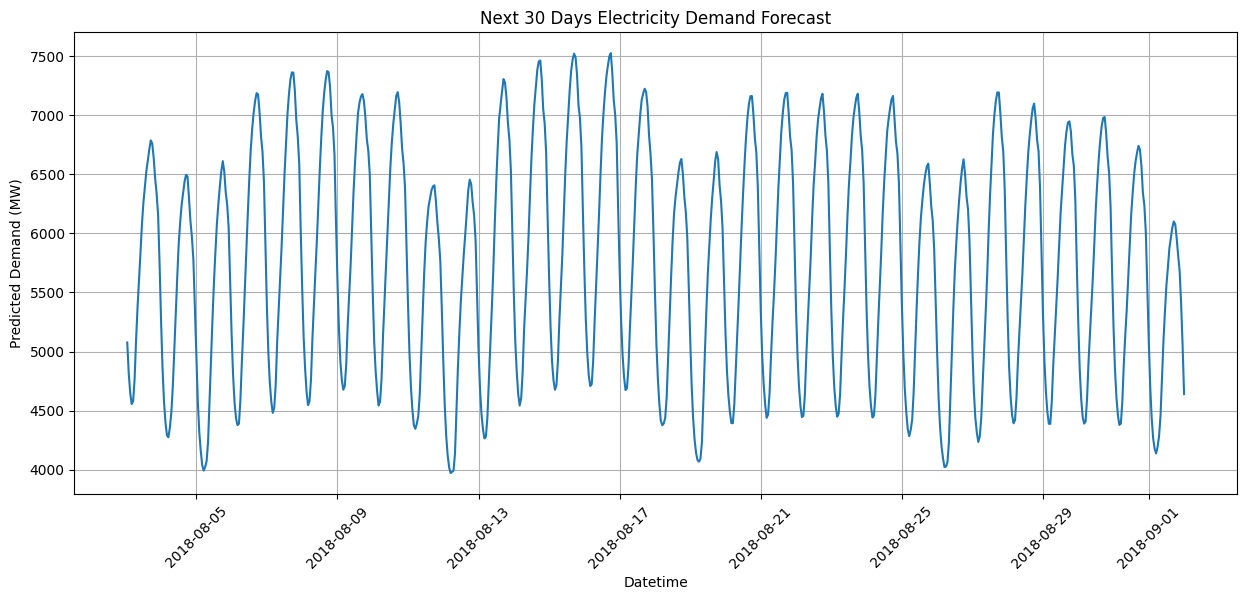

In [94]:
#Plot 30-day forecast
plt.figure(figsize=(15,6))

plt.plot(
    future_forecast["Datetime"],
    future_forecast["Predicted_MW"]
)

plt.title(
    "Next 30 Days Electricity Demand Forecast"
)

plt.xlabel("Datetime")
plt.ylabel("Predicted Demand (MW)")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [95]:
# Save forecast CSV
future_forecast.to_csv(
    "next_30_days_forecast.csv",
    index=False
)

In [96]:
#PJM dataset is U.S. electricity demand data, so use U.S. holidays:
# Get the years present in your dataset
start_year = df["Datetime"].dt.year.min()
end_year = df["Datetime"].dt.year.max()

# Create US holiday calendar
us_holidays = holidays.US(
    years=range(start_year, end_year + 1)
)

# Convert holiday dates to a set
holiday_dates = set(us_holidays.keys())

print("Number of holidays:", len(holiday_dates))

# Display some holidays
for date in sorted(holiday_dates)[:20]:
    print(date, us_holidays.get(date))


# Saving the hoilday_dates
import joblib
joblib.dump(
    holiday_dates,
    "holiday_dates.pkl"
)

print("holiday_dates.pkl saved successfully")

Number of holidays: 189
2002-01-01 New Year's Day
2002-01-21 Martin Luther King Jr. Day
2002-02-18 Washington's Birthday
2002-05-27 Memorial Day
2002-07-04 Independence Day
2002-09-02 Labor Day
2002-10-14 Columbus Day
2002-11-11 Veterans Day
2002-11-28 Thanksgiving Day
2002-12-25 Christmas Day
2003-01-01 New Year's Day
2003-01-20 Martin Luther King Jr. Day
2003-02-17 Washington's Birthday
2003-05-26 Memorial Day
2003-07-04 Independence Day
2003-09-01 Labor Day
2003-10-13 Columbus Day
2003-11-11 Veterans Day
2003-11-27 Thanksgiving Day
2003-12-25 Christmas Day
holiday_dates.pkl saved successfully


In [97]:
# Saving the Best Model :
import joblib

joblib.dump(
    xgb_model,
    "xgb_model.pkl"
)

['xgb_model.pkl']

In [98]:
# Saving the feature list :
joblib.dump(
    feature_cols,
    "feature_columns.pkl"
)

['feature_columns.pkl']

In [99]:
# Save the comparison table:
results_df.to_csv(
    "model_comparison.csv",
    index=False
)

In [100]:
# Save the dataset information :
metadata = {
    "target": "PJMW_MW",
    "frequency": "Hourly",
    "forecast_horizon_days": 30,
    "forecast_horizon_hours": 720,
    "best_model": "XGBoost"
}

joblib.dump(
    metadata,
    "metadata.pkl"
)

['metadata.pkl']